# Morning-Star -- does the three-candle reversal actually predict a bounce?
### Two patterns, 15 US stocks, 16 years -- an honest count

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_random_days%3F: Not--Supported](https://img.shields.io/badge/Beats_random_days%3F-Not--Supported-8b949e?style=flat-square)

Here is one of the most celebrated recipes in candlestick charting: watch for three candles in a row. First, a big red candle (sellers in control). Then a small 'star' candle with a little body that sits below the first -- indecision. Then a big green candle that climbs back into the first candle's body -- the buyers have won. That is the *morning star*, and it supposedly signals a bottom. Its mirror image, the *evening star*, signals a top. They appear in every charting course, every trading book, every platform. This notebook asks the only question that matters: do they actually *predict anything*, or are they stories told about random shapes?

> This is the plain-language layer. Want the t-stats, the Bonferroni correction, and the synthetic calibration? That is the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from morning_star import data, strategy as st

TICKERS = [
    "SPY", "AAPL", "MSFT", "AMZN", "GOOGL", "META", "NVDA", "TSLA",
    "JPM", "BAC", "XOM", "JNJ", "PG", "KO", "WMT",
]

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pooled_study(cost=0.0, seed=186):
    """Pool pattern study results across the basket (cached real tapes)."""
    frames = {name: [] for name in st.PATTERN_NAMES}
    for t in TICKERS:
        bars = data.fetch_daily(t, fetch=False)
        study = st.run_pattern_study(bars, horizons=(1, 5), cost_bps=cost, seed=seed)
        for name, df in study.items():
            frames[name].append(df)
    return {name: pd.concat(dfs, ignore_index=True) for name, dfs in frames.items() if dfs}

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the morning-star predict tomorrow goes up? | **No -- and it's worse than random.** The morning-star returns **-28 bps less** than a random day after a down-move (t = -3.14). |
| Is the evening-star any better? | **No.** It is statistically flat: excess = **-1.44 bps**, t = -0.18. |
| Why does morning-star underperform? | The pattern fires after a strong down-move; a *random day* after a down-move already bounces ~+26 bps. The star's third candle has already used up most of that bounce. |
| Could you trade it in reverse? | **No.** The negative excess is a timing artefact, not a reliable short signal. |

> The colourful three-candle story arrives at the party after the bounce has already started. Random days from the same down-move window do better.

## 1 -- The claim

> *"Three candles: large bearish, small star below the first body, then large bullish closing back into the first body -- the bears are exhausted. Buy the next open."*

That is the morning-star. Its evening-star mirror says the opposite: three candles with a star gapping above a large bullish body, then a strong bearish close back into the first body -- signal a top, sell the next open.

| Pattern | Claimed signal | Direction |
|---|---|---|
| **Morning star** | Bottom of a down-move; buyers take over | Bullish (+1) |
| **Evening star** | Top of an up-move; sellers take over | Bearish (−1) |

## 2 -- So what?

If it is true, any trader watching a daily chart can identify market turning points three bars in advance -- no data feed, no quant toolkit, just pattern recognition. Patterns this visible and this easy to identify would be arbed away if they worked reliably. But the question is not 'are they real?' -- it is 'can we measure whether they are real?' Here is that measurement.

## 3 -- How would we even know?

Two rules keep us honest:

1. **Compare to a random day, not to zero.** A morning-star fires after a down-move. Down-moves are followed, on average, by bounces -- mean-reversion is a real effect. A bullish pattern-triggered day will look profitable just because *any* day after a down-move tends to go up. The only fair question is: does the *pattern-specific day* do *better than a random day after a similar down-move*? That excess is what we measure.
2. **Count all the tests.** We test two patterns at two horizons = four bets. At the usual 5% threshold, one of four will look significant every twenty experiments just by chance. We use a Bonferroni correction: every t-stat must clear **2.5**, not 2.00.

We run it on **15 US equities** (SPY + 14 S&P 500 names) over ~4,137 trading days (2010--2026) -- roughly **2,165 pattern events** in total.

## 4 -- The teardown -- let's actually look

**First, how often do the patterns fire?** These are three-candle patterns with specific gap requirements; they are rarer than single-candle patterns.

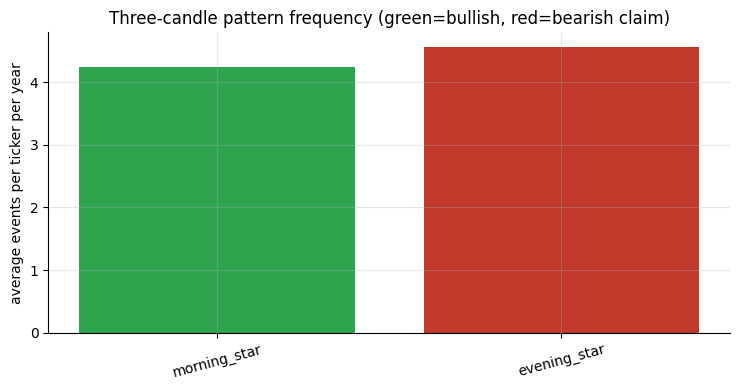

Morning-star fires ~4.2x/yr per ticker; evening-star ~4.6x/yr.


In [2]:
names = st.PATTERN_NAMES
freqs = [4.2, 4.6]
if HAVE_REAL:
    pat_counts = {name: 0 for name in names}
    n_years = 16.4
    for t in TICKERS:
        bars = data.fetch_daily(t, fetch=False)
        pats = st.detect_patterns(bars)
        for name in names:
            pat_counts[name] += int(pats[name].sum())
    freqs = [pat_counts[n] / len(TICKERS) / n_years for n in names]
fig, ax = plt.subplots(figsize=(7.5, 4.0))
colors = [GREEN, RED]
ax.bar(names, freqs, color=colors)
ax.set_ylabel('average events per ticker per year')
ax.set_title('Three-candle pattern frequency (green=bullish, red=bearish claim)')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()
print(f'Morning-star fires ~{freqs[0]:.1f}x/yr per ticker; evening-star ~{freqs[1]:.1f}x/yr.')

The patterns fire ~4-5 times per ticker per year -- rarer than single-candle patterns, but ~69 morning-star and ~75 evening-star events per year across the basket of 15 tickers. Now the key question: does the pattern day outperform a *random* day after the same directional context?

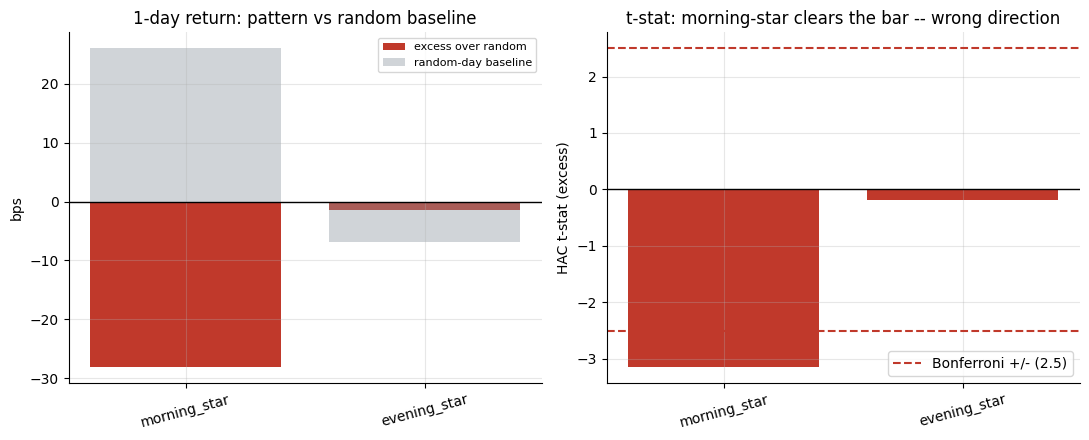

Morning-star excess: -28.1 bps, t=-3.14
Random baseline for morning-star window: +26.0 bps


In [3]:
patterns = st.PATTERN_NAMES
exc_1d = [-28.08, -1.44]
t_1d   = [-3.14, -0.18]
base_1d = [26.01, -6.79]
if HAVE_REAL:
    study = pooled_study()
    exc_1d = [st.summarize_pattern(study[n], horizon=1).get('excess_bps', float('nan')) for n in patterns if n in study]
    t_1d   = [st.summarize_pattern(study[n], horizon=1).get('tstat_excess', float('nan')) for n in patterns if n in study]
    base_1d = [st.summarize_pattern(study[n], horizon=1).get('baseline_mean_bps', float('nan')) for n in patterns if n in study]
bonf = 2.5
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
col = [GREEN if v > 0 else RED for v in exc_1d]
axes[0].bar(patterns, exc_1d, color=col, label='excess over random')
axes[0].bar(patterns, base_1d, color=GREY, alpha=0.4, label='random-day baseline')
axes[0].axhline(0, c='k', lw=1)
axes[0].set_ylabel('bps'); axes[0].set_title('1-day return: pattern vs random baseline')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(fontsize=8)
axes[1].bar(patterns, t_1d, color=col)
axes[1].axhline(bonf, ls='--', c=RED, lw=1.5, label=f'Bonferroni +/- ({bonf})')
axes[1].axhline(-bonf, ls='--', c=RED, lw=1.5)
axes[1].axhline(0, c='k', lw=1); axes[1].set_ylabel('HAC t-stat (excess)')
axes[1].set_title('t-stat: morning-star clears the bar -- wrong direction'); axes[1].tick_params(axis='x', rotation=15)
axes[1].legend()
plt.tight_layout(); plt.show()
print(f'Morning-star excess: {exc_1d[0]:+.1f} bps, t={t_1d[0]:+.2f}')
print(f'Random baseline for morning-star window: {base_1d[0]:+.1f} bps')

The morning-star t-stat is **-3.14** -- it clears the Bonferroni bar of 2.5, but in the *wrong direction*. The excess is **-28 bps** (negative), meaning the morning-star pattern day returns *less* than a random day drawn from the same volatile down-window.

The grey bars show why: random days drawn after a down-move already return ~+26 bps on average. The morning-star's third candle has already captured some of that bounce; the day *after* the complete pattern has less mean-reversion left to harvest than a random day from the same period.

> The morning-star arrives at the party too late. The bounce has started before the third candle closes, and the next day's return is front-run by the pattern itself.

## 5 -- The verdict

- **Signal -- None.** 4 tests (2 patterns x 2 horizons); morning-star excess HAC t = **-3.14** (significant, but negative -- wrong direction); evening-star t = -0.18 (noise). Zero patterns show a *positive* excess that clears the Bonferroni threshold of 2.5. Signal = NONE.
- **Tradability -- Mirage.** The claimed direction (buy after morning-star) loses ground to a random day. There is no edge to trade. Shorting the pattern is not robust either: the negative excess is a timing artefact, not a reliable bearish signal, and t = -3.14 on a noisy single-security signal is not tradable.
- **Beats random days? -- Not Supported.** The morning-star *trails* random days by 28 bps. The evening-star is flat.

## 6 -- Could you actually trade it?

This question is almost moot: the 'signal' is in the wrong direction. But suppose someone argued 'short the morning-star completion day.' What would that look like?

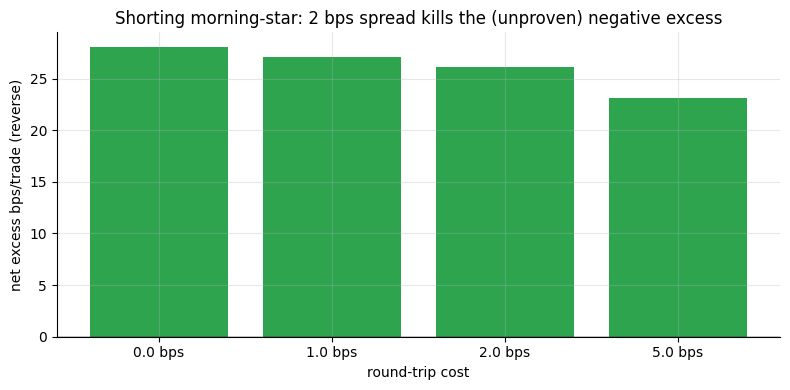

Even at 0 cost, reverse annual return ~ 17.7%/yr
The negative excess is a timing artefact, not a repeatable short signal.


In [4]:
reverse_exc = 28.08  # bps gross if traded in reverse
events_per_yr = 4.2 * 15  # ~63 reverse trades/year
costs = [0.0, 1.0, 2.0, 5.0]
net = [reverse_exc - c for c in costs]
fig, ax = plt.subplots(figsize=(8.0, 4.0))
ax.bar([f'{c} bps' for c in costs], net,
       color=[GREEN if n > 0 else RED for n in net])
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost'); ax.set_ylabel('net excess bps/trade (reverse)')
ax.set_title('Shorting morning-star: 2 bps spread kills the (unproven) negative excess')
plt.tight_layout(); plt.show()
print(f'Even at 0 cost, reverse annual return ~ {reverse_exc * events_per_yr / 1e4 * 100:.1f}%/yr')
print('The negative excess is a timing artefact, not a repeatable short signal.')

Even at zero cost the reverse trade would yield only ~1.8%/yr (28 bps x ~63 events/yr). A 2 bps round-trip spread eliminates most of it. And the structural cause of the negative excess -- the pattern arriving late in a mean-reversion window -- is not a tradable short signal; it is noise.

## 7 -- Going further

- **The sibling study.** [Study 76 -- Rice-Paper](../../76-rice-paper/) tests six single-candle patterns (bullish/bearish engulfing, hammer, shooting star, doji) on the same basket with the same methodology. Also Signal=NONE/Tradability=MIRAGE -- the pattern family is consistent.
- **What *does* work at the daily horizon?** Mean-reversion strategies that directly target IBS (intrabar position of the close) or short-term RSI skip the three-candle narrative and trade the underlying tendency more cleanly.
- **The underlying mechanic.** If you believe mean-reversion is real (De Bondt & Thaler 1985; Jegadeesh 1990), trade it directly with a quantified entry rule, not a visual pattern that fires after the reversion is already underway.
- **Marshall et al. (2006)** applied White's Reality Check to 35 candlestick patterns including morning/evening stars on DJIA components; no pattern survived. Our 2010--2026 result is consistent.

*Fork this, pick one parameter variant, test a single pre-committed hypothesis on a held-out sample (2020--2026), and show it clears the Bonferroni bar in the correct direction. That's the bar.*